In [1]:
# Tiny Temporal Graph Transformer (TGT) for Power-Flow Forecasting on IEEE-14 

# What this notebook does:
# 1) Load IEEE-14 topology from 'branch_data.parquet'
# 2) Load real time-series loads from 'bus_data.parquet' and flows from 'branch_data.parquet'
# 3) Train a tiny TGT to map past loads -> next-step line flows

import math, numpy as np, numpy.linalg as LA, networkx as nx, matplotlib.pyplot as plt, pandas as pd
import torch, torch.nn as nn, torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
#! Set working dir
import os
print(os.getcwd())
os.chdir("../")
print(os.getcwd())

f:\studium\Thesis_Repo\phase1_tgt_model
f:\studium\Thesis_Repo


In [3]:
# Load Bus and Branch DataFrames
bus_df = pd.read_parquet('data_out/phase1_baseline/case14_ieee/raw/bus_data.parquet')
branch_df = pd.read_parquet('data_out/phase1_baseline/case14_ieee/raw/branch_data.parquet')

# Build Edge Index from Branch Data
structure = branch_df[branch_df['load_scenario_idx'] == 0].sort_values("idx")
edge_index = list(structure[['from_bus', 'to_bus']].itertuples(index=False, name=None))

# print dims
m = len(edge_index)
n=bus_df['bus'].nunique()
print(f"Topology Loaded: n={n} Nodes, m={m} Edges")

# X: Input Loads (Active Power 'Pd')
loads_pivot = bus_df.pivot(index='load_scenario_idx', columns='bus', values='Pd').fillna(0)
# Y: Target Flows (Active Power Flow 'pf')
flows_pivot = branch_df.pivot(index='load_scenario_idx', columns='idx', values='pf').fillna(0)

# Convert to Numpy Arrays
loads_matrix = loads_pivot.values
flows_matrix = flows_pivot.values
print(f"shapes: Loads: {loads_matrix.shape}, Flows: {flows_matrix.shape}")

Topology Loaded: n=14 Nodes, m=20 Edges
shapes: Loads: (8751, 14), Flows: (8751, 20)


In [4]:
# create (X, Y) pairs:
# X: (lookback L) loads per node, Y: next-step line flows
L = 12 # Look back is 12 
Total_Time = len(loads_matrix)
X, Y = [], []

for t in range(L, Total_Time):
    input_window = loads_matrix[t-L : t]  # (L, n)
    X.append(input_window)
    target_flow = flows_matrix[t]  # (m,)
    Y.append(target_flow)
X = np.stack(X) # (N, L, n)
Y = np.stack(Y) # (N, m)

# Train / Val Split (80/20)
split_idx = int(0.8 * len(X))

Xtr, Ytr = X[:split_idx], Y[:split_idx]
Xva, Yva     = X[split_idx:], Y[split_idx:]

print(f"Dataset Created!")
print(f"Training Data:   X={Xtr.shape}, Y={Ytr.shape}")
print(f"Validation Data: X={Xva.shape},   Y={Yva.shape}")



Dataset Created!
Training Data:   X=(6991, 12, 14), Y=(6991, 20)
Validation Data: X=(1748, 12, 14),   Y=(1748, 20)


In [5]:
#  Normalize Data
X_mean = Xtr.mean(axis=(0, 1)); X_std  = Xtr.std(axis=(0, 1)) + 1e-5 # prevent div by 0 errors
Y_mean = Ytr.mean(axis=0)     ; Y_std  = Ytr.std(axis=0) + 1e-5 # prevent div by 0 errors

def normalize_x(data): return (data - X_mean) / X_std
def normalize_y(data): return (data - Y_mean) / Y_std

def denormalize_y(data): return (data * Y_std) + Y_mean

Xtr = normalize_x(Xtr)
Ytr = normalize_y(Ytr)
Xva = normalize_x(Xva)
Yva = normalize_y(Yva)

In [6]:
# Adjacency mask (neighbors + self)
A = np.zeros((n,n), dtype=bool)
for (i,j) in edge_index:
    A[i,j]=True; A[j,i]=True
for i in range(n): A[i,i]=True
A_mask = torch.from_numpy(A).to(device)

class SpatialAttention(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__(); self.h=n_heads; self.dk=d_model//n_heads
        self.q=nn.Linear(d_model,d_model); self.k=nn.Linear(d_model,d_model); self.v=nn.Linear(d_model,d_model); self.o=nn.Linear(d_model,d_model)
    def forward(self, x, mask):
        # x: (B, N, D)
        B,N,D = x.shape; H=self.h; dk=self.dk
        q=self.q(x).view(B,N,H,dk).transpose(1,2)
        k=self.k(x).view(B,N,H,dk).transpose(1,2)
        v=self.v(x).view(B,N,H,dk).transpose(1,2)
        s=(q@k.transpose(-2,-1))/math.sqrt(dk)
        m = mask.unsqueeze(0).unsqueeze(0).expand(B,H,N,N)
        s = s.masked_fill(~m, float('-inf'))
        a = torch.softmax(s, dim=-1)
        out = a@v
        out = out.transpose(1,2).contiguous().view(B,N,D)
        return self.o(out)

class TemporalBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff  = nn.Sequential(nn.Linear(d_model, 4*d_model), nn.GELU(), nn.Linear(4*d_model, d_model))
        self.ln2 = nn.LayerNorm(d_model)
    def forward(self, x):
        # x: (B, T, D)
        y,_ = self.attn(x,x,x); x=self.ln1(x+y)
        y = self.ff(x); x=self.ln2(x+y); return x

class TinyTGT(nn.Module):
    def __init__(self, n_nodes, n_edges, d_model=64, n_heads=4, n_temporal_layers=2):
        super().__init__(); self.n_nodes=n_nodes; self.n_edges=n_edges
        self.enc = nn.Linear(1, d_model)        # encode scalar load -> embedding
        self.spat = SpatialAttention(d_model, n_heads)
        self.temporal = nn.ModuleList([TemporalBlock(d_model, n_heads) for _ in range(n_temporal_layers)])
        self.edge_mlp = nn.Sequential(nn.Linear(2*d_model, 2*d_model), nn.GELU(), nn.Linear(2*d_model,1))
        src = torch.tensor([i for (i,_) in edge_index], device=device)
        dst = torch.tensor([j for (_,j) in edge_index], device=device)
        self.register_buffer('src', src); self.register_buffer('dst', dst)
    def forward(self, loads_seq, mask):
        # loads_seq: (B, T, N)
        B,T,N = loads_seq.shape
        x = self.enc(loads_seq.reshape(B*T*N,1)).view(B,T,N,-1)   # (B,T,N,D)
        # Spatial attention per time
        x_ = self.spat(x.view(B*T, N, -1), mask).view(B, T, N, -1)
        # Temporal attention per node
        x_bn = x_.permute(0,2,1,3).contiguous().view(B*N, T, -1)
        for layer in self.temporal:
            x_bn = layer(x_bn)
        hT = x_bn[:,-1,:].view(B, N, -1)
        # Edge readout
        h_src = hT[:, self.src, :]; h_dst = hT[:, self.dst, :]
        return self.edge_mlp(torch.cat([h_src, h_dst], dim=-1)).squeeze(-1)  # (B, m)

model = TinyTGT(n_nodes=n, n_edges=m, d_model=64, n_heads=4).to(device)
sum(p.numel() for p in model.parameters())


133377

In [ ]:
def to_tensors(X, Y):
    return torch.from_numpy(X).float().to(device), torch.from_numpy(Y).float().to(device)

Xtr_t, Ytr_t = to_tensors(Xtr, Ytr)
Xva_t, Yva_t = to_tensors(Xva, Yva)

opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss() 
batch_size = 128
epochs = 300  # increase for better accuracy

def minibatches(X, Y, bs):
    idx = torch.randperm(X.shape[0])
    for i in range(0, len(idx), bs):
        j = idx[i:i+bs]
        yield X[j], Y[j]

history = {'train_loss': [], 'val_loss': []}

for ep in range(1, epochs+1):
    model.train(); train_loss=0.0
    for xb, yb in minibatches(Xtr_t, Ytr_t, batch_size):
        opt.zero_grad(set_to_none=True)
        yhat = model(xb, A_mask)
        loss = loss_fn(yhat, yb)
        loss.backward(); opt.step()
        train_loss += loss.item()*xb.size(0)
    train_loss /= Xtr_t.size(0)
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(Xva_t, A_mask), Yva_t).item()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {ep}: train MSE={train_loss:.6f} | val MSE={val_loss:.6f}")

Epoch 1: train MSE=0.561865 | val MSE=0.360480
Epoch 2: train MSE=0.467531 | val MSE=0.306362
Epoch 3: train MSE=0.389879 | val MSE=0.277476
Epoch 4: train MSE=0.371571 | val MSE=0.271439
Epoch 5: train MSE=0.362460 | val MSE=0.270789
Epoch 6: train MSE=0.344050 | val MSE=0.256613
Epoch 7: train MSE=0.337743 | val MSE=0.259698
Epoch 8: train MSE=0.335109 | val MSE=0.251654
Epoch 9: train MSE=0.331177 | val MSE=0.250370
Epoch 10: train MSE=0.323825 | val MSE=0.245181
Epoch 11: train MSE=0.321302 | val MSE=0.239506
Epoch 12: train MSE=0.318854 | val MSE=0.241186
Epoch 13: train MSE=0.318163 | val MSE=0.256196
Epoch 14: train MSE=0.314707 | val MSE=0.237348
Epoch 15: train MSE=0.305306 | val MSE=0.235446
Epoch 16: train MSE=0.300026 | val MSE=0.234409
Epoch 17: train MSE=0.303277 | val MSE=0.230515
Epoch 18: train MSE=0.291355 | val MSE=0.236367
Epoch 19: train MSE=0.293782 | val MSE=0.232188
Epoch 20: train MSE=0.283221 | val MSE=0.239001
Epoch 21: train MSE=0.284820 | val MSE=0.215779
E

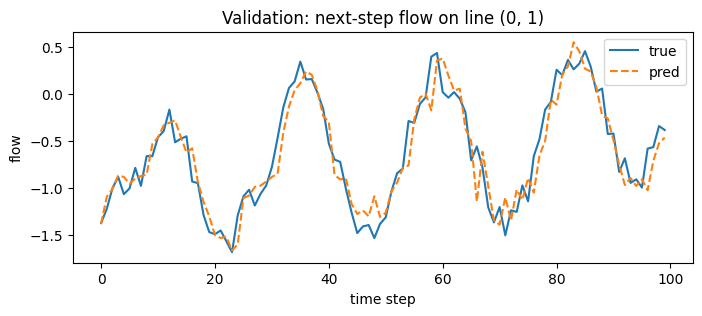

In [8]:
with torch.no_grad():
    pred = model(Xva_t, A_mask).cpu().numpy()

line_id = 0  # pick one line to visualize
true_line = Yva[:, line_id]
pred_line = pred[:, line_id]

plt.figure(figsize=(8,3))
plt.plot(true_line[:100], label='true')
plt.plot(pred_line[:100], label='pred', linestyle='--')
plt.title(f'Validation: next-step flow on line {edge_index[line_id]}')
plt.xlabel('time step'); plt.ylabel('flow'); plt.legend(); plt.show()

In [9]:
print(model)

TinyTGT(
  (enc): Linear(in_features=1, out_features=64, bias=True)
  (spat): SpatialAttention(
    (q): Linear(in_features=64, out_features=64, bias=True)
    (k): Linear(in_features=64, out_features=64, bias=True)
    (v): Linear(in_features=64, out_features=64, bias=True)
    (o): Linear(in_features=64, out_features=64, bias=True)
  )
  (temporal): ModuleList(
    (0-1): 2 x TemporalBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
  

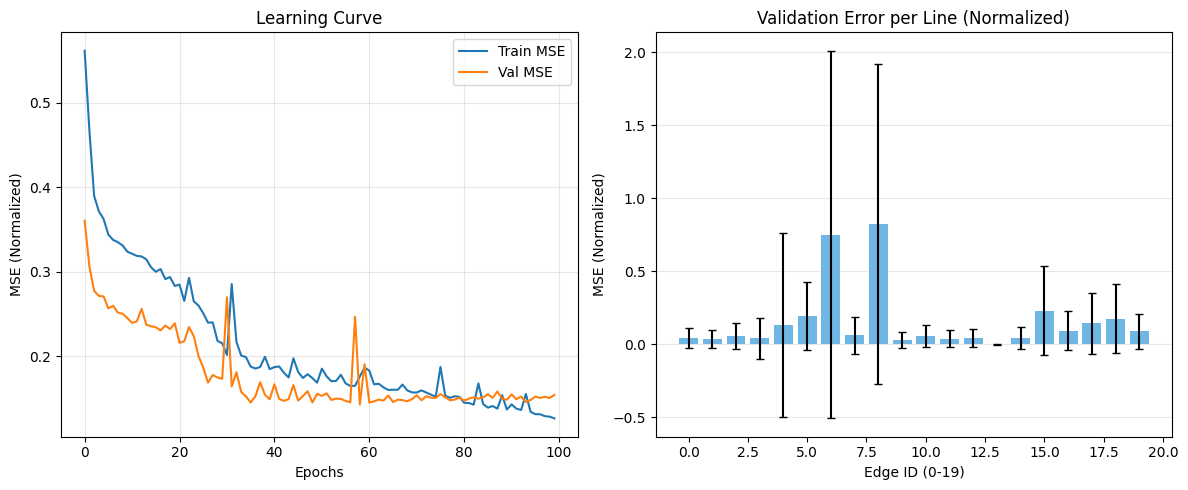

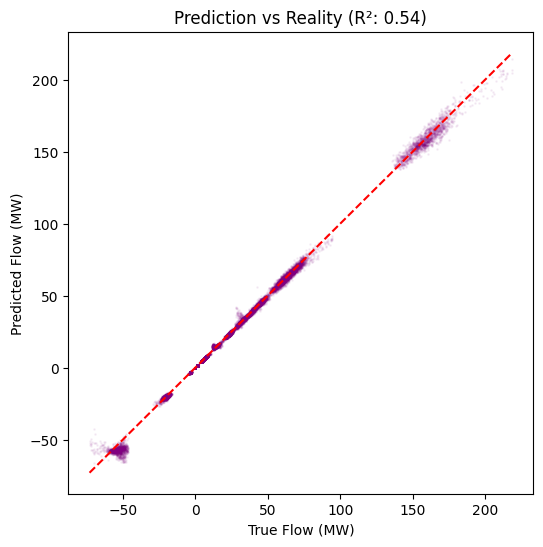

,Edge ID,From,To,Flow %,MSE (Norm),Std (Norm),MSE (Real),Std (Real),Avg (Real),R² Score
0,0,0,1,27.24,0.0425,0.0685,18.06,29.11,159.83,0.8891
1,1,0,4,11.71,0.0383,0.0621,3.17,5.14,68.70,0.8946
2,2,1,2,10.29,0.0544,0.0897,3.77,6.22,60.34,0.8431
6,6,3,4,9.19,0.7523,1.2594,32.85,54.99,-53.91,-1.0477
3,3,1,3,7.64,0.0400,0.1381,1.47,5.05,44.84,0.8796
9,9,4,5,6.33,0.0301,0.0531,0.78,1.38,37.16,0.9139
4,4,1,4,5.46,0.1311,0.6285,2.59,12.41,32.02,0.5909
7,7,3,6,3.99,0.0615,0.1265,0.52,1.08,23.39,0.8239
14,14,6,8,3.99,0.0440,0.0729,0.37,0.62,23.39,0.8740
5,5,2,3,3.46,0.1946,0.2358,1.42,1.73,-20.33,0.5729


In [39]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

output_dir = 'phase1_tgt_model/outputs/'
# Plot Learning Curves (Normalized)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train MSE')
plt.plot(history['val_loss'], label='Val MSE')
plt.title('Learning Curve')
plt.xlabel('Epochs'); plt.ylabel('MSE (Normalized)')
plt.legend(); plt.grid(True, alpha=0.3)

# calc Final MSE (Global & Per-Edge)
model.eval()
with torch.no_grad():
    pred_norm = model(Xva_t, A_mask)
    true_norm = Yva_t
    sq_errors = (pred_norm - true_norm) ** 2
    edge_mse_mean = sq_errors.mean(dim=0).cpu().numpy() 
    edge_mse_std  = sq_errors.std(dim=0).cpu().numpy()  
    y_pred_np = pred_norm.cpu().numpy()
    y_true_np = true_norm.cpu().numpy()
    
# Plot Per-Edge MSE Bar Chart
plt.subplot(1, 2, 2)
x_pos = np.arange(len(edge_mse_mean))
plt.bar(x_pos, edge_mse_mean, yerr=edge_mse_std, capsize=3, 
        color='#3498db', alpha=0.7, ecolor='black')
plt.xlabel('Edge ID (0-19)')
plt.ylabel('MSE (Normalized)')
plt.title('Validation Error per Line (Normalized)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_path_1 = os.path.join(output_dir, 'learning_and_bar.png')
plt.savefig(save_path_1, dpi=300)
plt.show()

pred_real = (y_pred_np * Y_std) + Y_mean
true_real = (y_true_np * Y_std) + Y_mean
sq_errors_real = (pred_real - true_real) ** 2
edge_mse_real = sq_errors_real.mean(axis=0)
edge_std_real = sq_errors_real.std(axis=0)
edge_avg_real  = true_real.mean(axis=0)
edge_abs_avg = np.abs(true_real).mean(axis=0)
total_system_flow = edge_abs_avg.sum()

r2 = r2_score(true_real, pred_real)

plt.figure(figsize=(6, 6))
plt.scatter(true_real.flatten(), pred_real.flatten(), alpha=0.05, s=1, color='purple')
plt.plot([true_real.min(), true_real.max()], [true_real.min(), true_real.max()], 'r--')
plt.xlabel("True Flow (MW)")
plt.ylabel("Predicted Flow (MW)")
plt.title(f"Prediction vs Reality (R²: {r2:.2f})")
save_path_2 = os.path.join(output_dir, 'scatter_plot.png')
plt.savefig(save_path_2, dpi=300)
plt.show()

#  stats Table
line_report = []
for i in range(len(edge_mse_mean)):
    r2 = r2_score(y_true_np[:, i], y_pred_np[:, i])
    u, v = edge_index[i]
    line_report.append({
        "Edge ID": i,
        "From": u,
        "To": v,
        "Flow %": f"{(edge_abs_avg[i] / total_system_flow) * 100:.2f}",
        "MSE (Norm)": f"{edge_mse_mean[i]:.4f}", 
        "Std (Norm)": f"{edge_mse_std[i]:.4f}",
        "MSE (Real)": f"{edge_mse_real[i]:.2f}",
        "Std (Real)": f"{edge_std_real[i]:.2f}",
        "Avg (Real)": f"{edge_avg_real[i]:.2f}",
        "R² Score": f"{r2:.4f}"
    })
df_results = pd.DataFrame(line_report)
df_results = df_results.sort_values(
    by="Flow %",
    key=lambda s: s.str.rstrip('%').astype(float),
    ascending=False
)
display(df_results)
df_results.to_csv(os.path.join(output_dir, 'model_stats.csv'), index=False, float_format='%.4f')

- plot train and val curves over epochs
- train/val loss (=MSE) +- std (this easily calculatedble?)
- MSE's for every bus
- 

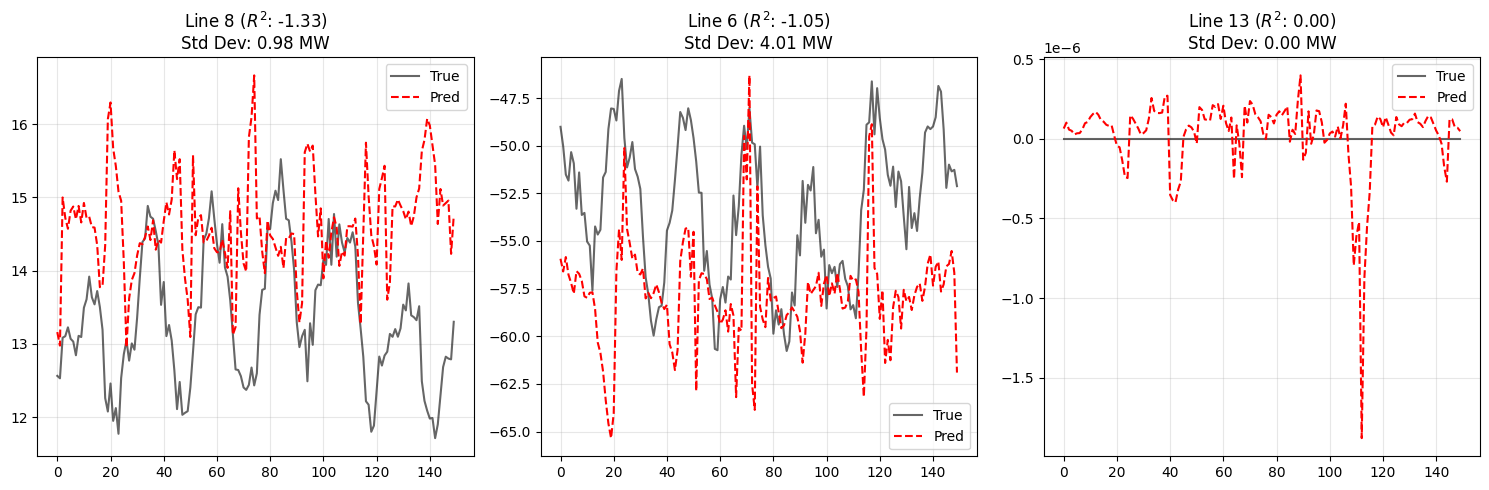

In [ ]:
# ---------------------------------------------------------
# CELL 9: Visual Diagnostics of Failed Lines
# ---------------------------------------------------------
bad_lines = [8, 6, 13]  # The ones you identified

plt.figure(figsize=(15, 5))

for i, line_idx in enumerate(bad_lines):
    plt.subplot(1, 3, i+1)
    
    # Get Real MW Data
    truth = true_real[:, line_idx]
    pred  = pred_real[:, line_idx]
    
    # Plot
    plt.plot(truth[:150], label='True', color='black', alpha=0.6)
    plt.plot(pred[:150], label='Pred', color='red', linestyle='--')
    
    # Add Variance info to title
    std_dev = np.std(truth)
    plt.title(f"Line {line_idx} ($R^2$: {line_report[line_idx]['R2 Score']:.2f})\nStd Dev: {std_dev:.2f} MW")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()